<a href="https://colab.research.google.com/github/prakriti459/LAB2ML/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
data= pd.read_csv("USA_Housing.csv")

In [5]:
data.shape

(5000, 7)

In [11]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [9]:
data.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


In [12]:
data.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


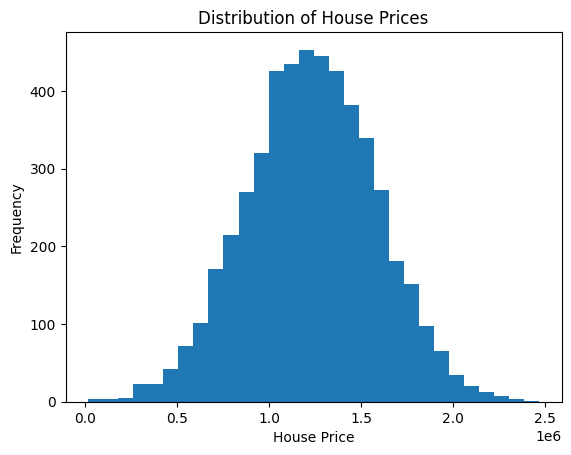

In [20]:
plt.figure()
plt.hist(data["Price"], bins=30)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()


In [21]:
corr = data.corr()


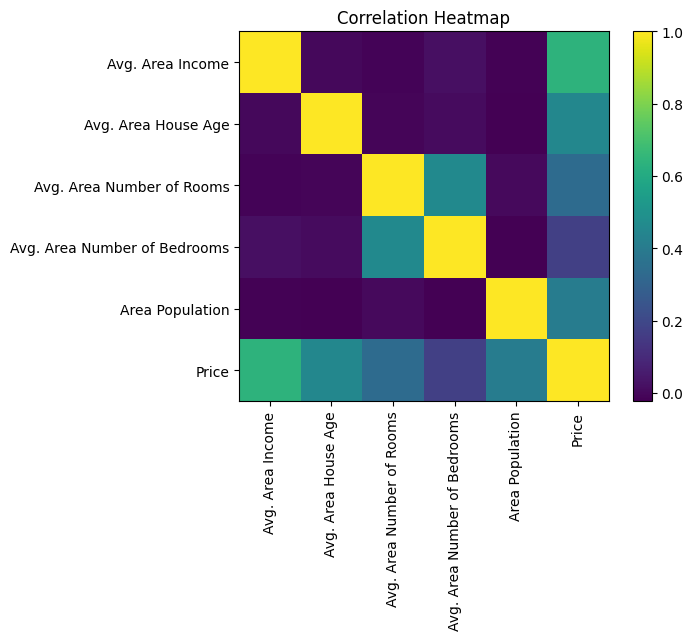

In [22]:
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()


In [29]:
# Calculate Q1, Q3 and IQR
Q1 = data["Price"].quantile(0.25)
Q3 = data["Price"].quantile(0.75)
IQR = Q3 - Q1


In [30]:
# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [31]:
# Detect outliers
outliers = data[(data["Price"] < lower_bound) | (data["Price"] > upper_bound)]
outliers


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
90,48904.983269,4.844973,5.448956,3.38,32960.753070,2.018981e+05
256,91159.418327,6.536045,7.373851,3.01,54861.091097,2.298379e+06
263,40366.616291,4.902940,7.617118,5.07,16349.365394,1.520719e+05
355,87266.340225,8.248959,7.234261,5.00,45161.187677,2.249123e+06
465,90592.469609,7.700132,9.708803,5.19,37223.876167,2.469066e+06
622,90890.485814,7.510171,7.595487,6.21,45519.256271,2.252243e+06
693,107701.748378,7.143522,8.518608,3.29,37619.439929,2.332111e+06
696,49851.134784,4.684996,5.259695,3.04,32511.846268,2.832081e+05
715,92280.497474,7.258627,8.222633,4.31,38004.145211,2.237778e+06
901,89089.432075,7.146246,9.179994,5.29,49782.152070,2.271113e+06


In [32]:
data = data[(data["Price"] >= lower_bound) & (data["Price"] <= upper_bound)]


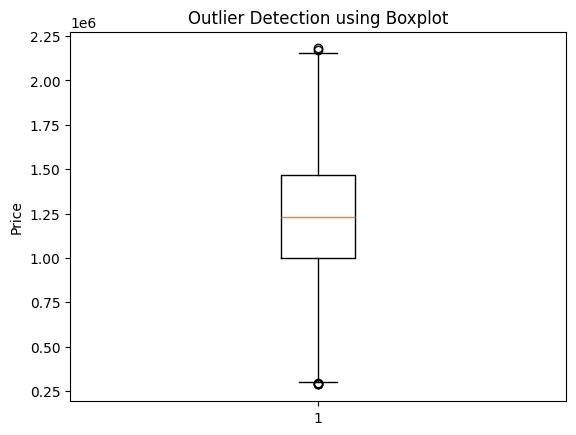

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(data["Price"])
plt.title("Outlier Detection using Boxplot")
plt.ylabel("Price")
plt.show()


In [24]:
if "Address" in data.columns:
    data.drop("Address", axis=1, inplace=True)



In [25]:
X = data.drop("Price", axis=1)
y = data["Price"]

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
